In [1]:
# Import flux api
from terndata import flux

In [2]:
# Get sites and their locations available. This may take quite a while as it needs to load the dataset for each site to get the locations.
# output is a geopandas.GeoDataFrame
sites = flux.get_sites()
sites

,site,longitude,latitude,vegetation,canopy height,start,end,geometry
0,AdelaideRiver,131.117800,-13.076900,Woody Savanna,16.4m,2007-10-17 11:30:00,2009-05-24 06:00:00,POINT (131.1178 -13.0769)
1,AliceSpringsMulga,133.249300,-22.282800,Canopy + three types of understorey (vegetatio...,4.4,2010-09-03 00:00:00,2026-04-23 00:00:00,POINT (133.2493 -22.2828)
2,AlpinePeatland,147.320833,-36.862222,,0.3m,2017-04-12 18:30:00,2022-06-20 23:30:00,POINT (147.32083 -36.86222)
3,Boolcoomatta,140.699650,-31.884930,Saltbush plain / chenopod shrubland,0.32,2025-08-13 18:00:00,2026-04-07 00:00:00,POINT (140.69965 -31.88493)
4,Boyagin,116.938560,-32.477090,Dry schlerophyll woodland,13,2017-10-20 13:00:00,2026-04-23 00:00:00,POINT (116.93856 -32.47709)
5,CalperumChowilla,140.587700,-34.002700,Mallee,3,2010-07-30 11:00:00,2026-04-23 00:00:00,POINT (140.5877 -34.0027)
6,CapeTribulation,145.446922,-16.103219,lowland complex mesophyll vine forest,25m,2010-01-01 00:00:00,2018-11-02 12:00:00,POINT (145.44692 -16.10322)
7,Collie,116.237000,-33.420000,Dry schlerophyll woodland,12.0m,2017-08-04 00:30:00,2019-11-11 13:30:00,POINT (116.237 -33.42)
8,CowBay,145.427150,-16.238190,lowland complex mesophyll vine forest,26,2009-01-01 09:00:00,2026-04-23 00:00:00,POINT (145.42715 -16.23819)
9,CumberlandPlain,150.723600,-33.615200,Dry sclerophyll forest,24,2014-01-01 00:30:00,2026-04-23 00:00:00,POINT (150.7236 -33.6152)


<Axes: >

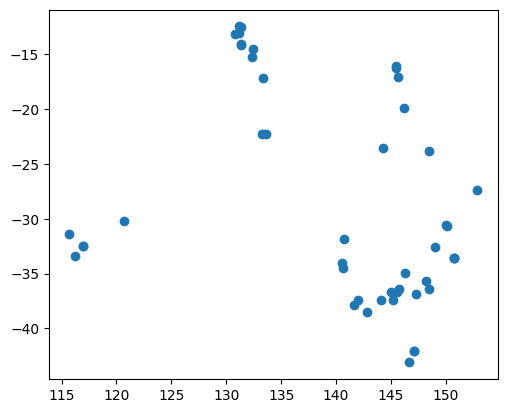

In [3]:
# plot sites
sites.plot()

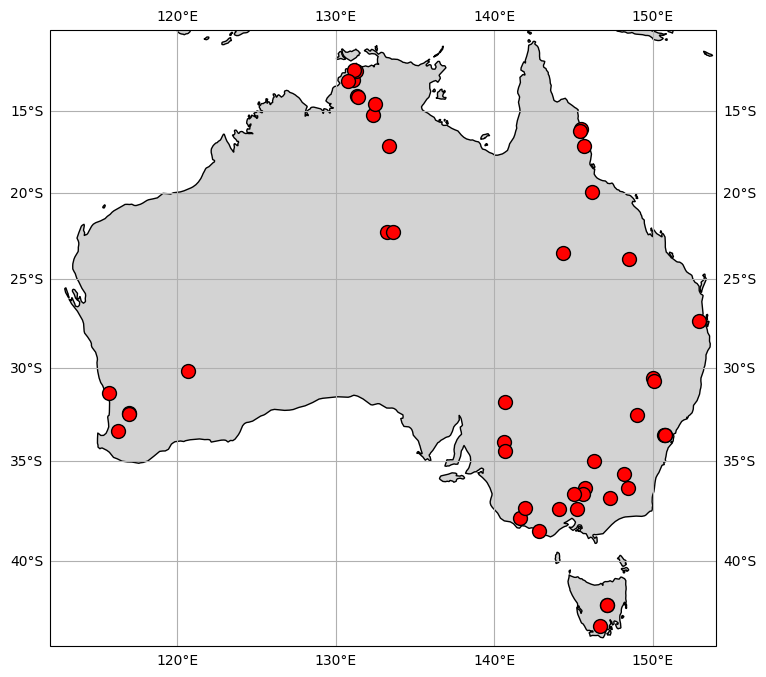

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Create a figure and set up an axes with a Mercator projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# 2. Set the bounding box for Australia [min_lon, max_lon, min_lat, max_lat]
# We tell Cartopy these numbers are standard Geodetic (lat/lon) coordinates
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

# 3. Add map features (equivalent to Basemap's resolution='i')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))  # Intermediate resolution
ax.add_feature(cfeature.BORDERS.with_scale('50m'))    # Country borders
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray')

# Optional: Add gridlines with labels
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# 4. Draw your points onto the map
# CRITICAL: transform=ccrs.PlateCarree() translates raw lat/lon to the map's projection
ax.scatter(
    sites["longitude"], 
    sites["latitude"], 
    color='red', 
    marker='o', 
    s=100,                  # Size of the points
    edgecolor='black',      # Border around points
    zorder=5,               # Ensures points stay on top of the map layer
    transform=ccrs.PlateCarree() 
)

plt.show()

In [5]:
# List the dataset versions available for a site
versions = flux.get_versions("Boyagin")
versions

['2020',
 '2021_v1',
 '2022_v1',
 '2022_v2',
 '2023_v1',
 '2023_v2',
 '2024_v1',
 '2024_v2',
 '2025_v1',
 '2025_v2',
 '2026_v1',
 '2026_v2']

In [6]:
# Get processing-levels of a dataset for a specified site and version
levels = flux.get_processing_levels("Boyagin", "2026_v2")
levels

['L3', 'L4', 'L5', 'L6']

In [ ]:
# Get global attributes for 30min dataset from a site
global_attributes = flux.get_global_attributes("Boyagin")
global_attributes

{'Conventions': 'CF-1.8',
 'acknowledgement': 'This work used eddy covariance data collected by the TERN Ecosystem \nProcesses facility. Ecosystem Processes would like to acknowledge the financial support of the \nAustralian Federal Government via the National Collaborative Research Infrastructure Scheme \nand the Education Investment Fund.',
 'altitude': '300m',
 'canopy_height': '13',
 'comment': 'CF metadata, OzFlux standard variable names',
 'contact': 'jason.beringer@uwa.edu.au',
 'coverage_flux_L3': '87%',
 'coverage_meteorology_L3': '94%',
 'coverage_radiation_L3': '86%',
 'coverage_soil_L3': '97%',
 'data_link': 'http://data.ozflux.org.au/',
 'date_created': '2026-07-01 09:28:40',
 'elevation': '484',
 'featureType': 'timeSeries',
 'fluxnet_id': 'AU-Boy',
 'history': 'June 2021 processing',
 'institution': 'University of Western Australia',
 'latitude': '-32.47709',
 'license': 'https://creativecommons.org/licenses/by/4.0/',
 'license_name': 'CC BY 4.0',
 'longitude': '116.9385

In [8]:
# Get variables of 30min dataset from a site 
flux.get_variables("Boyagin")

['crs',
 'station_name',
 'AH',
 'AH_QCFlag',
 'CO2',
 'CO2_QCFlag',
 'Fa',
 'Fa_QCFlag',
 'Fco2',
 'Fco2_QCFlag',
 'Fe',
 'Fe_QCFlag',
 'Fg',
 'Fg_QCFlag',
 'Fh',
 'Fh_QCFlag',
 'Fld',
 'Fld_QCFlag',
 'Flu',
 'Flu_QCFlag',
 'Fm',
 'Fm_QCFlag',
 'Fn',
 'Fn_QCFlag',
 'Fsd',
 'Fsd_QCFlag',
 'Fsu',
 'Fsu_QCFlag',
 'H2O',
 'H2O_QCFlag',
 'Precip',
 'Precip_QCFlag',
 'RH',
 'RH_QCFlag',
 'SH',
 'SH_QCFlag',
 'SHD',
 'SHD_QCFlag',
 'Sco2_single',
 'Sco2_single_QCFlag',
 'Sws',
 'Sws_QCFlag',
 'Ta',
 'Ta_QCFlag',
 'Ts',
 'Ts_QCFlag',
 'VP',
 'VP_QCFlag',
 'VPD',
 'VPD_QCFlag',
 'Wd',
 'Wd_QCFlag',
 'Ws',
 'Ws_QCFlag',
 'ps',
 'ps_QCFlag',
 'ustar',
 'ustar_QCFlag',
 'time',
 'latitude',
 'longitude']

In [9]:
# Get 30min dataset variable's attribute
flux.get_attributes("Boyagin", "2026_v2", "L6", ["Fco2", "Fe", "Fh", "Fm"])

{'Fco2': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '83%',
  'coverage_L4': '83%',
  'coverage_L5': '100%',
  'coverage_L6': '100%',
  'description_L5': ', turbulence filter applied, gap filled using SOLO, SOLO',
  'height': '23m',
  'instrument': 'CSAT3, Li-7500A',
  'long_name': 'CO2 flux',
  'standard_name': 'surface_upward_mole_flux_of_carbon_dioxide',
  'statistic_type': 'average',
  'units': 'umol/m^2/s',
  'ustar_threshold_2017': '0.35535561228253937',
  'ustar_threshold_2018': '0.3495571839732151',
  'ustar_threshold_2019': '0.3723127914415676',
  'ustar_threshold_2020': '0.3543672728316978',
  'ustar_threshold_2021': '0.3602385929564937',
  'ustar_threshold_2022': '0.3585573340784232',
  'ustar_threshold_2023': '0.3249074891154746',
  'ustar_threshold_2024': '0.3756593252316089',
  'ustar_threshold_2025': '0.3677980311077323',
  'ustar_threshold_2026': '0.3348024898066412',
  'valid_range': array([-20.,  30.])},
 'Fe': {'_CoordinateAxes': 'time latitude l

In [10]:
# Get 30min dataset variable's attributes, default latest version and L3 processing-level
flux.get_attributes("Boyagin", variables=["AH", "CO2"])

{'AH': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '97%',
  'height': '23m',
  'instrument': 'HMP45',
  'long_name': 'Absolute humidity',
  'standard_name': 'mass_concentration_of_water_vapor_in_air',
  'statistic_type': 'average',
  'units': 'g/m^3',
  'valid_range': array([ 0., 40.])},
 'CO2': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '86%',
  'height': '23.0',
  'instrument': 'Li-7500A',
  'long_name': 'CO2 concentration',
  'standard_name': 'mole_fraction_of_carbon_dioxide_in_air',
  'statistic_type': 'average',
  'units': 'umol/mol',
  'valid_range': array([250., 900.])}}

In [11]:
# temporal range for 30min dataset (default)
flux.get_temporal_range("Boyagin", "2026_v2", "L6")


('2017-10-20T13:00:00.000000000', '2026-04-23T00:00:00.000000000')

In [12]:
# Get 30min dataset from a site, Output is a Xarray.Dataset
ds = flux.get_dataset("Boyagin", "2026_v2", "L3")
ds

<xarray.Dataset> Size: 52MB
Dimensions:             (time: 151429, latitude: 1, longitude: 1)
Coordinates:
  * time                (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 202...
  * latitude            (latitude) float64 8B -32.48
  * longitude           (longitude) float64 8B 116.9
Data variables: (12/58)
    crs                 int32 4B ...
    station_name        |S64 64B ...
    AH                  (time, latitude, longitude) float64 1MB ...
    AH_QCFlag           (time, latitude, longitude) int32 606kB ...
    CO2                 (time, latitude, longitude) float64 1MB ...
    CO2_QCFlag          (time, latitude, longitude) int32 606kB ...
    ...                  ...
    Ws                  (time, latitude, longitude) float64 1MB ...
    Ws_QCFlag           (time, latitude, longitude) int32 606kB ...
    ps                  (time, latitude, longitude) float64 1MB ...
    ps_QCFlag           (time, latitude, longitude) int32 606kB ...
    ustar               (time, latitude, longitude) float64 1MB ...
    ustar_QCFlag        (time, latitude, longitude) int32 606kB ...
Attributes: (12/43)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [13]:
# Get 30min dataset from a site, and set missing value. Output is a Xarray.Dataset
import numpy as np
ds2 = flux.get_dataset("Boyagin", "2026_v2", "L3", missing_as_nan=True)

# print out the variables with na value, and a count of na
for var in list(ds2.variables.keys()):
  if var in list(ds2.coords) + ["crs", "station_name"]:
    continue
  fill_count = int(np.sum((ds2[var] == -9999)).values)
  na_count = int(np.sum((np.isnan(ds2[var]))).values)
  fill_count2 = int(np.sum((ds2[var] == -9999)).values)
  na_count2 = int(np.sum((np.isnan(ds2[var]))).values)
  if fill_count or na_count:
      print(f"{var}: fill: {fill_count2} ({fill_count}), na: {na_count2} ({na_count})")
    

AH: fill: 0 (0), na: 3108 (3108)
CO2: fill: 0 (0), na: 20391 (20391)
Fa: fill: 0 (0), na: 19893 (19893)
Fco2: fill: 0 (0), na: 25381 (25381)
Fe: fill: 0 (0), na: 21785 (21785)
Fg: fill: 0 (0), na: 4498 (4498)
Fh: fill: 0 (0), na: 21820 (21820)
Fld: fill: 0 (0), na: 22111 (22111)
Flu: fill: 0 (0), na: 21159 (21159)
Fm: fill: 0 (0), na: 9800 (9800)
Fn: fill: 0 (0), na: 19765 (19765)
Fsd: fill: 0 (0), na: 14429 (14429)
Fsu: fill: 0 (0), na: 21622 (21622)
H2O: fill: 0 (0), na: 5636 (5636)
Precip: fill: 0 (0), na: 7944 (7944)
RH: fill: 0 (0), na: 3108 (3108)
SH: fill: 0 (0), na: 5636 (5636)
SHD: fill: 0 (0), na: 5636 (5636)
Sco2_single: fill: 0 (0), na: 22336 (22336)
Sws: fill: 0 (0), na: 4479 (4479)
Ta: fill: 0 (0), na: 3096 (3096)
Ts: fill: 0 (0), na: 4478 (4478)
VP: fill: 0 (0), na: 3108 (3108)
VPD: fill: 0 (0), na: 3108 (3108)
Wd: fill: 0 (0), na: 3477 (3477)
Ws: fill: 0 (0), na: 3502 (3502)
ps: fill: 0 (0), na: 5613 (5613)
ustar: fill: 0 (0), na: 9208 (9208)


In [14]:
# Get 30min datasets from 2 sites
datasets = flux.get_datasets(["Boyagin", "AliceSpringsMulga"] , "2026_v2", "L6")
datasets

{'Boyagin': <xarray.Dataset> Size: 81MB
 Dimensions:             (time: 149111, latitude: 1, longitude: 1)
 Coordinates:
   * time                (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 202...
   * latitude            (latitude) float64 8B -32.48
   * longitude           (longitude) float64 8B 116.9
 Data variables: (12/88)
     crs                 int32 4B ...
     station_name        |S64 64B ...
     AH                  (time, latitude, longitude) float64 1MB ...
     AH_QCFlag           (time, latitude, longitude) int32 596kB ...
     CO2                 (time, latitude, longitude) float64 1MB ...
     CO2_QCFlag          (time, latitude, longitude) int32 596kB ...
     ...                  ...
     Ws                  (time, latitude, longitude) float64 1MB ...
     Ws_QCFlag           (time, latitude, longitude) int32 596kB ...
     ps                  (time, latitude, longitude) float64 1MB ...
     ps_QCFlag           (time, latitude, longitude) int32 596kB ...
     u

In [15]:
# Get a subset of 30min dataset, slice to 2 variables
subset = flux.get_subset("Boyagin",  "2026_v2", "L3", ["AH", "CO2"])
subset

<xarray.Dataset> Size: 5MB
Dimensions:     (time: 151429, latitude: 1, longitude: 1)
Coordinates:
  * time        (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2026-06-10T...
  * latitude    (latitude) float64 8B -32.48
  * longitude   (longitude) float64 8B 116.9
Data variables:
    AH          (time, latitude, longitude) float64 1MB ...
    CO2         (time, latitude, longitude) float64 1MB ...
    AH_QCFlag   (time, latitude, longitude) int32 606kB ...
    CO2_QCFlag  (time, latitude, longitude) int32 606kB ...
Attributes: (12/43)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [16]:
# Get a subset of 30min dataset from multiple sites, slice to 2 variables
subsets= flux.get_subsets(["Boyagin", "AliceSpringsMulga"],  "2026_v2", "L3", ["AH", "CO2"])
subsets

{'Boyagin': <xarray.Dataset> Size: 5MB
 Dimensions:     (time: 151429, latitude: 1, longitude: 1)
 Coordinates:
   * time        (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2026-06-10T...
   * latitude    (latitude) float64 8B -32.48
   * longitude   (longitude) float64 8B 116.9
 Data variables:
     AH          (time, latitude, longitude) float64 1MB ...
     CO2         (time, latitude, longitude) float64 1MB ...
     AH_QCFlag   (time, latitude, longitude) int32 606kB ...
     CO2_QCFlag  (time, latitude, longitude) int32 606kB ...
 Attributes: (12/43)
     Conventions:              CF-1.8
     acknowledgement:          This work used eddy covariance data collected b...
     altitude:                 300m
     canopy_height:            13
     comment:                  CF metadata, OzFlux standard variable names
     contact:                  jason.beringer@uwa.edu.au
     ...                       ...
     time_zone:                Australia/Perth
     title:                 

In [21]:
# Get a subset of 30min dataset, slice to 2 variables, and temporal range 
subset = flux.get_subset("Boyagin",  "2026_v2", "L3", ["AH", "CO2"], start="2008-01-01 12:30", end="2008-12-31 00:00", keep_qcflags=False)
subset

<xarray.Dataset> Size: 16B
Dimensions:    (time: 0, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 0B 
  * latitude   (latitude) float64 8B -32.48
  * longitude  (longitude) float64 8B 116.9
Data variables:
    AH         (time, latitude, longitude) float64 0B ...
    CO2        (time, latitude, longitude) float64 0B ...
Attributes: (12/43)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [24]:
# Save as netcdf file locally
from datetime import datetime
start = datetime.strptime("2008-1-1 12:30", "%Y-%m-%d %H:%M")
end = datetime.strptime("2008-11-30 00:00", "%Y-%m-%d %H:%M")
subset2 = flux.get_subset("Boyagin",  "2026_v2", "L3", ["AH", "CO2"], start, end, missing_as_nan=True)

# save data as netcdf file
subset2.to_netcdf("/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/subset2.nc")


In [23]:
# Get 30-min dataset for a site
flux.get_l6_dataset("Boyagin", "2026_v2", "30min")

<xarray.Dataset> Size: 81MB
Dimensions:             (time: 149111, latitude: 1, longitude: 1)
Coordinates:
  * time                (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 202...
  * latitude            (latitude) float64 8B -32.48
  * longitude           (longitude) float64 8B 116.9
Data variables: (12/88)
    crs                 int32 4B ...
    station_name        |S64 64B ...
    AH                  (time, latitude, longitude) float64 1MB ...
    AH_QCFlag           (time, latitude, longitude) int32 596kB ...
    CO2                 (time, latitude, longitude) float64 1MB ...
    CO2_QCFlag          (time, latitude, longitude) int32 596kB ...
    ...                  ...
    Ws                  (time, latitude, longitude) float64 1MB ...
    Ws_QCFlag           (time, latitude, longitude) int32 596kB ...
    ps                  (time, latitude, longitude) float64 1MB ...
    ps_QCFlag           (time, latitude, longitude) int32 596kB ...
    ustar               (time, latitude, longitude) float64 1MB ...
    ustar_QCFlag        (time, latitude, longitude) int32 596kB ...
Attributes: (12/56)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [36]:
# Get daily dataset for a site
flux.get_l6_dataset("Boyagin", "2026_v2", "daily")

<xarray.Dataset> Size: 1MB
Dimensions:          (time: 3106, latitude: 1, longitude: 1)
Coordinates:
  * time             (time) datetime64[ns] 25kB 2017-10-21T00:30:00 ... 2026-...
  * latitude         (latitude) float64 8B -32.48
  * longitude        (longitude) float64 8B 116.9
Data variables: (12/72)
    crs              int32 4B ...
    station_name     |S64 64B ...
    AH               (time, latitude, longitude) float64 25kB ...
    AH_QCFlag        (time, latitude, longitude) int32 12kB ...
    CO2              (time, latitude, longitude) float64 25kB ...
    CO2_QCFlag       (time, latitude, longitude) int32 12kB ...
    ...               ...
    Ws               (time, latitude, longitude) float64 25kB ...
    Ws_QCFlag        (time, latitude, longitude) int32 12kB ...
    ps               (time, latitude, longitude) float64 25kB ...
    ps_QCFlag        (time, latitude, longitude) int32 12kB ...
    ustar            (time, latitude, longitude) float64 25kB ...
    ustar_QCFlag     (time, latitude, longitude) int32 12kB ...
Attributes: (12/56)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [37]:
# Get monthly dataset for a site
flux.get_l6_dataset("Boyagin", "2026_v2", "monthly")

<xarray.Dataset> Size: 44kB
Dimensions:          (time: 102, latitude: 1, longitude: 1)
Coordinates:
  * time             (time) datetime64[ns] 816B 2017-11-01T00:30:00 ... 2026-...
  * latitude         (latitude) float64 8B -32.48
  * longitude        (longitude) float64 8B 116.9
Data variables: (12/72)
    crs              int32 4B ...
    station_name     |S64 64B ...
    AH               (time, latitude, longitude) float64 816B ...
    AH_QCFlag        (time, latitude, longitude) int32 408B ...
    CO2              (time, latitude, longitude) float64 816B ...
    CO2_QCFlag       (time, latitude, longitude) int32 408B ...
    ...               ...
    Ws               (time, latitude, longitude) float64 816B ...
    Ws_QCFlag        (time, latitude, longitude) int32 408B ...
    ps               (time, latitude, longitude) float64 816B ...
    ps_QCFlag        (time, latitude, longitude) int32 408B ...
    ustar            (time, latitude, longitude) float64 816B ...
    ustar_QCFlag     (time, latitude, longitude) int32 408B ...
Attributes: (12/56)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [38]:
# Get annual dataset for a site
flux.get_l6_dataset("Boyagin", "2026_v2", "annual")

<xarray.Dataset> Size: 4kB
Dimensions:          (time: 10, latitude: 1, longitude: 1)
Coordinates:
  * time             (time) datetime64[ns] 80B 2017-01-01 ... 2026-01-01
  * latitude         (latitude) float64 8B -32.48
  * longitude        (longitude) float64 8B 116.9
Data variables: (12/72)
    crs              int32 4B ...
    station_name     |S64 64B ...
    AH               (time, latitude, longitude) float64 80B ...
    AH_QCFlag        (time, latitude, longitude) int32 40B ...
    CO2              (time, latitude, longitude) float64 80B ...
    CO2_QCFlag       (time, latitude, longitude) int32 40B ...
    ...               ...
    Ws               (time, latitude, longitude) float64 80B ...
    Ws_QCFlag        (time, latitude, longitude) int32 40B ...
    ps               (time, latitude, longitude) float64 80B ...
    ps_QCFlag        (time, latitude, longitude) int32 40B ...
    ustar            (time, latitude, longitude) float64 80B ...
    ustar_QCFlag     (time, latitude, longitude) int32 40B ...
Attributes: (12/56)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [39]:
# Get cumulative dataset for a site
flux.get_l6_dataset("Boyagin", "2026_v2", "cumulative", missing_as_nan=True)

<xarray.Dataset> Size: 37MB
Dimensions:          (time: 149111, latitude: 1, longitude: 1)
Coordinates:
  * time             (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2026-0...
  * latitude         (latitude) float64 8B -32.48
  * longitude        (longitude) float64 8B 116.9
Data variables: (12/32)
    crs              float64 8B ...
    station_name     object 8B ...
    ER               (time, latitude, longitude) float64 1MB ...
    ER_QCFlag        (time, latitude, longitude) float64 1MB ...
    ER_LL            (time, latitude, longitude) float64 1MB ...
    ER_LL_QCFlag     (time, latitude, longitude) float64 1MB ...
    ...               ...
    NEP_LT           (time, latitude, longitude) float64 1MB ...
    NEP_LT_QCFlag    (time, latitude, longitude) float64 1MB ...
    NEP_SOLO         (time, latitude, longitude) float64 1MB ...
    NEP_SOLO_QCFlag  (time, latitude, longitude) float64 1MB ...
    Precip           (time, latitude, longitude) float64 1MB ...
    Precip_QCFlag    (time, latitude, longitude) float64 1MB ...
Attributes: (12/56)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             36
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [27]:
# Get non-existent dataset
flux.get_l6_dataset("CalperumChowilla", "2023_v2", "cumulative")

Exception: Error: fail to get L6 dataset for site 'CalperumChowilla', version '2023_v2': Requested 'cumulative' dataset is not found!

In [29]:
import os
cwd = os.getcwd()

In [38]:
# export 30min dataset as oneflux csv;
flux.export_oneflux_csv(f"{cwd}/exports/oneflux", "Boyagin", "2026_v1", "L3")

['/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2017.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2018.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2019.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2020.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2021.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2022.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2023.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2024.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2025.csv',
 '/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/oneflux/AU-Boy_qcv_2026.csv']

In [ ]:
# export 30min dataset as Excel workbook;
flux.export_as_excel(f"{cwd}/exports/Boyagin_L3.xlsx", "Boyagin", "2026_v2", "L3")

'/Users/uqjsanc2/projects/R_I_Week_workshop/Flux/exports/Boyagin_L3.xlsx'

In [46]:
xds = flux.get_dataset("CalperumChowilla", "2026_v2", "L3", missing_as_nan=True)
xds

<xarray.Dataset> Size: 126MB
Dimensions:             (time: 277138, latitude: 1, longitude: 1)
Coordinates:
  * time                (time) datetime64[ns] 2MB 2010-07-30T11:00:00 ... 202...
  * latitude            (latitude) float64 8B -34.0
  * longitude           (longitude) float64 8B 140.6
Data variables: (12/58)
    crs                 float64 8B ...
    station_name        object 8B ...
    AH                  (time, latitude, longitude) float64 2MB ...
    AH_QCFlag           (time, latitude, longitude) float64 2MB ...
    CO2                 (time, latitude, longitude) float64 2MB ...
    CO2_QCFlag          (time, latitude, longitude) float64 2MB ...
    ...                  ...
    Ws                  (time, latitude, longitude) float64 2MB ...
    Ws_QCFlag           (time, latitude, longitude) float64 2MB ...
    ps                  (time, latitude, longitude) float64 2MB ...
    ps_QCFlag           (time, latitude, longitude) float64 2MB ...
    ustar               (time, latitude, longitude) float64 2MB ...
    ustar_QCFlag        (time, latitude, longitude) float64 2MB ...
Attributes: (12/43)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 60m
    canopy_height:            3
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  ozfluxtech@adelaide.edu.au
    ...                       ...
    time_zone:                Australia/Adelaide
    title:                    Flux tower data set from the Calperum site for ...
    tower_height:             20
    vegetation:               Mallee
    DODS.strlen:              8
    DODS.dimName:             name_strlen

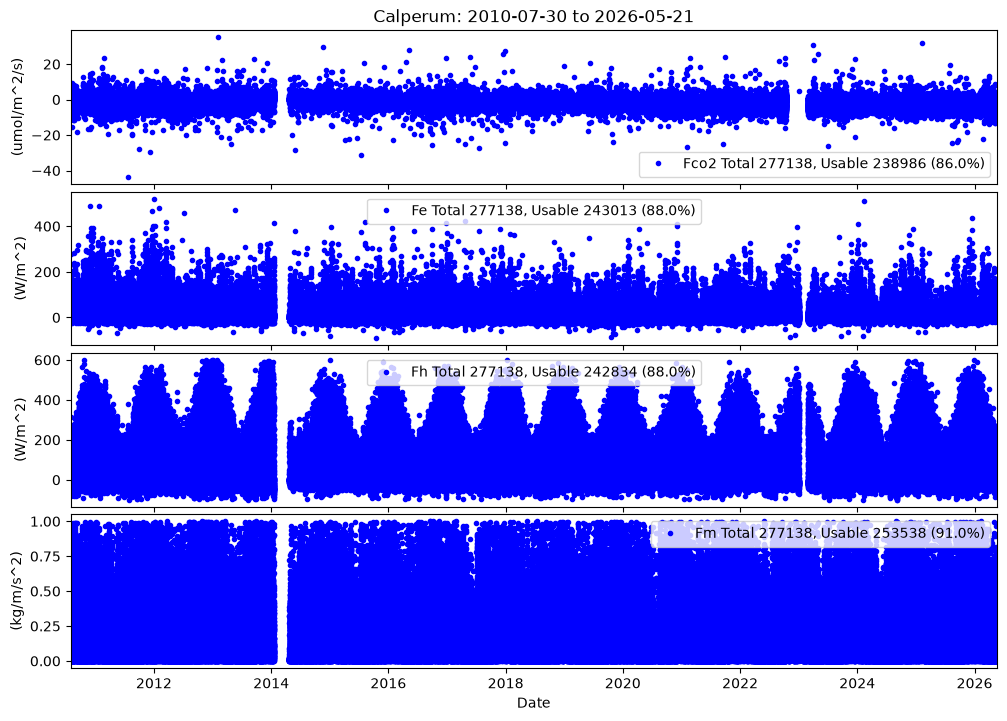

In [ ]:
from terndata.flux import plot

# time-series plot 
# 17 Jan 2024 bushfire in Calperum Mallee SuperSite: damaged tower
plot.plot_timeseries(xds, ["Fco2", "Fe", "Fh", "Fm"])

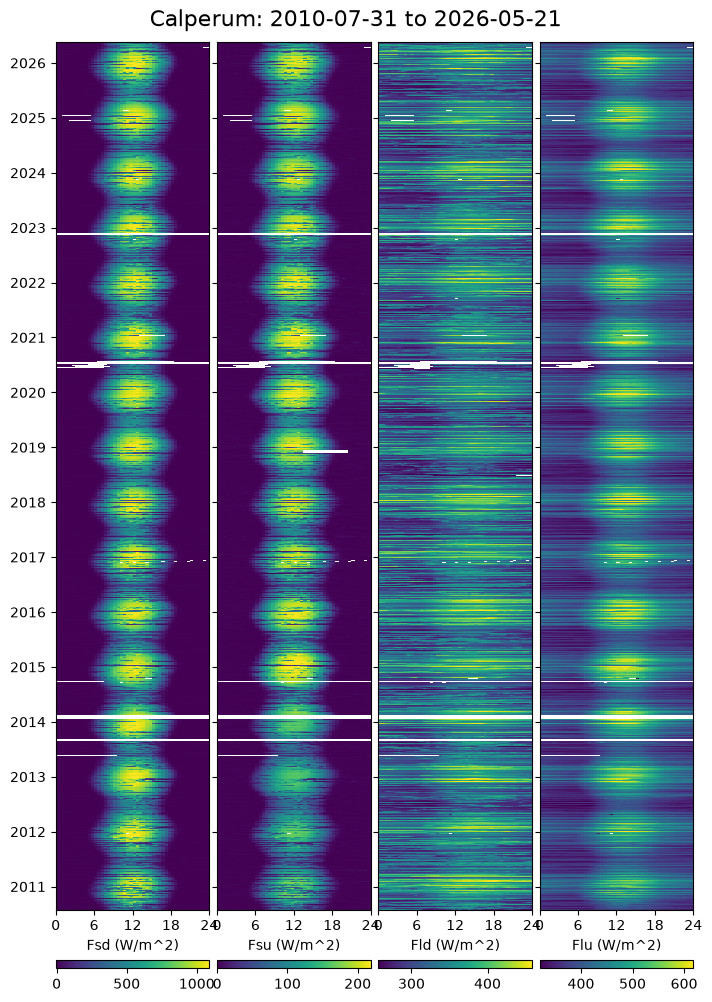

In [ ]:
# Fingerprints plot
plot.plot_fingerprints(xds, ["Fsd", "Fsu", "Fld", "Flu"])